># ⚜️Proyecto 02
* Buscar los datos de las acciones 
* Hacer el analisis de las acciones
  * cotizacion maxima
  * cotizcion minima
* Envio de E-mail con los resultados del analisis

>## 💹*Buscar Acciones* 

In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# 1. Leer el archivo (Asegúrate de que no haya espacios antes de 'df')
df = pd.read_csv(r"outputs/aapl.csv", index_col="Date", parse_dates=True)

# 2. Redondear
df = df.round(2)

# 3. Mostrar
display(df.head())

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2025-08-14 00:00:00-04:00,233.61,234.67,230.41,232.34,51916300,0.0,0.0
2025-08-15 00:00:00-04:00,233.55,233.83,228.90,231.15,56038700,0.0,0.0
2025-08-18 00:00:00-04:00,231.26,232.68,229.67,230.45,37476200,0.0,0.0
2025-08-19 00:00:00-04:00,230.84,232.43,228.91,230.12,39402600,0.0,0.0
2025-08-20 00:00:00-04:00,229.54,230.03,225.34,225.58,42263900,0.0,0.0


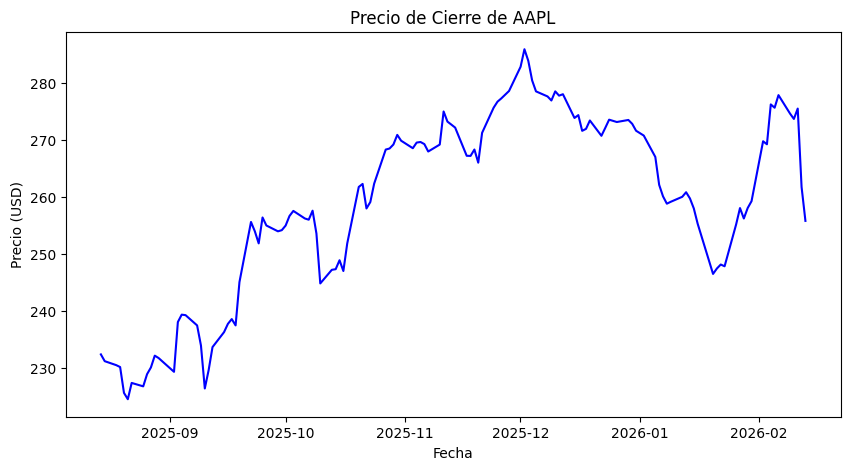

In [2]:
# 4. Graficar
plt.figure(figsize=(10, 5))
plt.plot(df.index, df["Close"], label="Precio de Cierre", color="blue")
plt.title("Precio de Cierre de AAPL")
plt.xlabel("Fecha")
plt.ylabel("Precio (USD)")
plt.show() 

In [3]:
close_table = df[["Open", "Close"]]
display(close_table.head())

,Open,Close
Date,,
2025-08-14 00:00:00-04:00,233.61,232.34
2025-08-15 00:00:00-04:00,233.55,231.15
2025-08-18 00:00:00-04:00,231.26,230.45
2025-08-19 00:00:00-04:00,230.84,230.12
2025-08-20 00:00:00-04:00,229.54,225.58


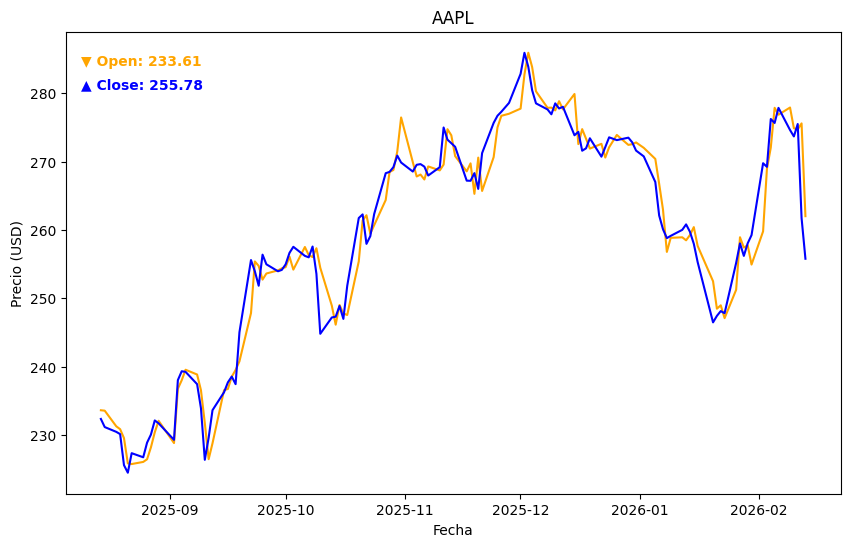

In [4]:
plt.figure(figsize=(10, 6))
plt.plot(df.index, df["Open"], label="Apertura", color="orange")
plt.plot(df.index, df["Close"], label="Cierre", color="blue")
plt.title("AAPL")
plt.xlabel("Fecha")
plt.ylabel("Precio (USD)")
# Caja para Apertura (Naranja)
plt.text(
    0.02,
    0.95,
    f"▼ Open: {df['Open'].iloc[0]:.2f}",
    transform=plt.gca().transAxes,
    color="orange",
    fontweight="bold",
    fontsize=10,
    verticalalignment="top",
)

# Caja para Cierre (Azul) - la bajamos un poco (0.90) para que no se traslapen
plt.text(
    0.02,
    0.90,
    f"▲ Close: {df['Close'].iloc[-1]:.2f}",
    transform=plt.gca().transAxes,
    color="blue",
    fontweight="bold",
    fontsize=10,
    verticalalignment="top",
)
plt.show()

>## 📈PLOTLY BIBLIOTECA


In [5]:
%pip install plotly
import plotly.graph_objects as go
import plotly.io as pio


# 1. Crear la figura
fig = go.Figure()

# 2. Añadir la línea de Apertura
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=df["Open"],
        mode="lines",
        name="Apertura",
        line=dict(color="orange"),
    )
)

# 3. Añadir la línea de Cierre
fig.add_trace(
    go.Scatter(
        x=df.index, y=df["Close"], mode="lines", name="Cierre", line=dict(color="blue")
    )
)

# 4. Configurar el diseño y el comportamiento del cursor
fig.update_layout(
    title="Precio AAPL Interactiva",
    xaxis_title="Fecha",
    yaxis_title="Precio (USD)",
    hovermode="x unified",  # Esto hace que al pasar el cursor muestre ambos valores a la vez
    legend=dict(x=0.01, y=0.99)),  # Posición de la leyenda

# 5. Añadir botones de rango de tiempo para un acabado profesional
fig.update_xaxes(
    rangeselector=dict(
        buttons=list([
            dict(count=1, label="1m", step="month", stepmode="backward"),
            dict(count=6, label="6m", step="month", stepmode="backward"),
            dict(step="all", label="Todo")
        ])
    )
)
fig.show()

Note: you may need to restart the kernel to use updated packages.


In [6]:
import plotly.express as px

# Mira qué fácil es hacer la misma gráfica con Express:
fig = px.line(df, y=["Open", "Close"], title="AAPL")
fig.show()

In [7]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 1. Preparar Datos e Indicador
df["MA20"] = df["Close"].rolling(window=20).mean()

# Lógica del Semáforo: Determinamos el color del fondo para el último dato
ultimo_precio = df["Close"].iloc[-1]
ultima_ma20 = df["MA20"].iloc[-1]

if ultimo_precio > ultima_ma20:
    color_semaforo = "rgba(0, 255, 0, 0.1)"  # Verde muy transparente
    texto_estado = "ESTADO: COMPRA (Alcista) 🟢"
else:
    color_semaforo = "rgba(255, 0, 0, 0.1)"  # Rojo muy transparente
    texto_estado = "ESTADO: VENTA (Bajista) 🔻"

# 2. Crear Figura con Subplots
fig = make_subplots(
    rows=2,
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.05,
    subplot_titles=(f"AAPL - {texto_estado}", "Volumen"),
    row_width=[0.3, 0.7],
)

# 3. Añadir Velas
fig.add_trace(
    go.Candlestick(
        x=df.index,
        open=df["Open"],
        high=df["High"],
        low=df["Low"],
        close=df["Close"],
        name="Precio",
    ),
    row=1,
    col=1,
)

# 4. Añadir Media Móvil
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=df["MA20"],
        line=dict(color="orange", width=2),
        name="Media Móvil 20d",
    ),
    row=1,
    col=1,
)

# 5. Añadir Volumen
fig.add_trace(
    go.Bar(x=df.index, y=df["Volume"], name="Volumen", marker_color="blue"),
    row=2,
    col=1,
)

# 6. EL SEMÁFORO (Fondo dinámico)
fig.add_hrect(
    y0=df["Low"].min(),
    y1=df["High"].max(),
    fillcolor=color_semaforo,
    opacity=0.5,
    layer="below",
    line_width=0,
    row=1,
    col=1,
)

# 7. Configuración Final
fig.update_layout(
    title=f"SISTEMA DE DECISIÓN AAPLinc: {texto_estado}",
    template="plotly_dark",
    height=800,
    hovermode="x unified",
    xaxis_rangeslider_visible=False,
)

fig.show()

# Exportar para tu exposición
fig.write_html("Semaforo_AAPL.html")
print(f"SUGERENCIA DE MOVIMIENTO: {texto_estado}.AAPLinc listo.")

SUGERENCIA DE MOVIMIENTO: ESTADO: VENTA (Bajista) 🔻.AAPLinc listo.
